In [2]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained, ttest_im_sess
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants

# Representational geometry at session 3
*Compare with model components below

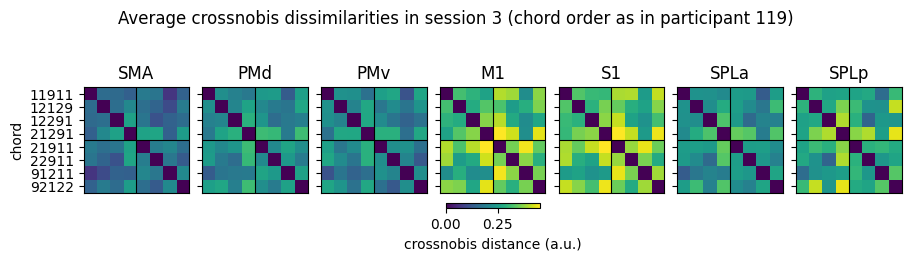

In [5]:
sn = 116
session = 3

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(9, 2.5))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for sn in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs_raw.within_session.{session}.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=get_trained_and_untrained(sn))
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([])
    ax.set_yticks(np.arange(8))
    #ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

axs[0].set_ylabel('chord')

fig.colorbar(im, ax=axs, fraction=.03, label='crossnobis distance (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3 (chord order as in participant {sn})')

fig.savefig(f'figures/crossnobis_example_{sn}.pdf')

plt.show()

# Crossnobis dissimilarities between activity patterns for trained and untrained chords
In M1 and S1, activity patterns for trained chords are more distant among each other compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.525324   15  0.607037  [-0.02, 0.01]   SMA        3
3  -0.428684   15  0.674246  [-0.02, 0.01]   PMd        3
6  -0.160328   15  0.874762  [-0.03, 0.02]   PMv        3
9  -0.462000   15  0.650711  [-0.05, 0.03]    M1        3
12 -0.920580   15  0.371838  [-0.05, 0.02]    S1        3
15 -0.934185   15  0.365004  [-0.04, 0.02]  SPLa        3
18 -0.555040   15  0.587050  [-0.04, 0.03]  SPLp        3
7  -0.117995   15  0.907637  [-0.03, 0.03]   PMv        9
13  0.736212   15  0.472959  [-0.03, 0.06]    S1        9
10  0.779425   15  0.447853  [-0.02, 0.05]    M1        9
4  -0.859589   15  0.403545  [-0.03, 0.01]   PMd        9
1   0.252532   15  0.804058  [-0.02, 0.02]   SMA        9
16  0.022808   15  0.982104  [-0.03, 0.03]  SPLa        9
19  0.118887   15  0.906942  [-0.03, 0.03]  SPLp        9
5  -0.072418   15  0.943226  [-0.01, 0.01]   PMd       23
2  -0.361927   15  0.722454  [-0.01, 0.01]   SMA       23
14  0.413635  

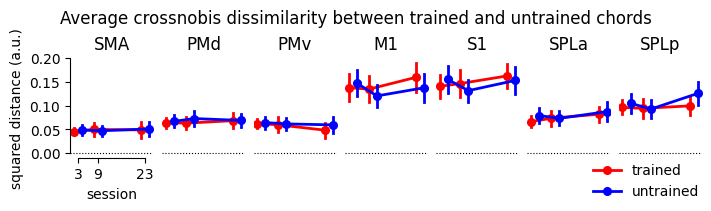

In [6]:
hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist = dist[(dist.Hem=='L') & (dist.chord.isin(hue_order))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average crossnobis dissimilarity between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

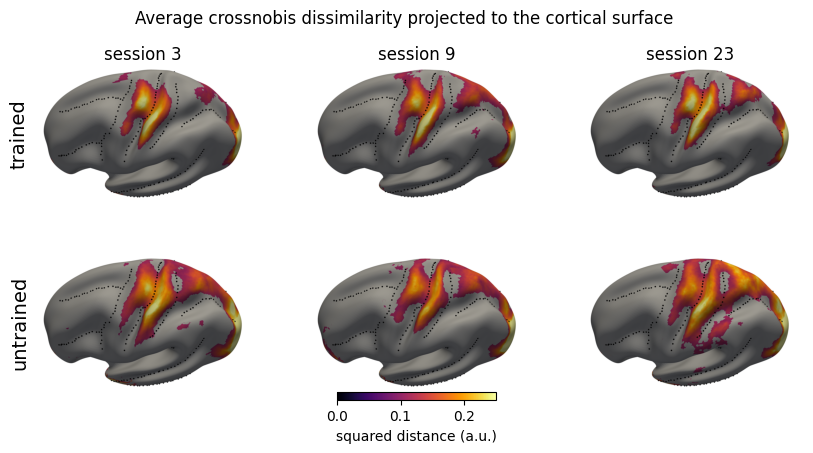

In [24]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('encoding-trained')
    untr_col = cols.index('encoding-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='squared distance (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

# Angle between activity patterns for trained and untrained chords
The angles between activity patterns for trained chords are also wider compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.265236   15  0.794438  [-0.05, 0.04]   SMA        3
3  -0.404422   15  0.691611  [-0.04, 0.03]   PMd        3
6  -0.355721   15  0.727003  [-0.05, 0.04]   PMv        3
9  -0.673288   15  0.511005  [-0.06, 0.03]    M1        3
12 -0.514883   15  0.614138  [-0.05, 0.03]    S1        3
15 -0.499947   15  0.624366  [-0.06, 0.04]  SPLa        3
18 -0.532071   15  0.602470  [-0.05, 0.03]  SPLp        3
7   0.167035   15  0.869573  [-0.04, 0.05]   PMv        9
13  0.894696   15  0.385081  [-0.03, 0.06]    S1        9
10  0.235200   15  0.817234  [-0.04, 0.05]    M1        9
4  -0.035644   15  0.972036  [-0.04, 0.04]   PMd        9
1  -0.382016   15  0.707808  [-0.04, 0.03]   SMA        9
16  0.666996   15  0.514905  [-0.03, 0.05]  SPLa        9
19  0.478656   15  0.639086  [-0.02, 0.03]  SPLp        9
5   0.598854   15  0.558207  [-0.02, 0.04]   PMd       23
2   0.024712   15  0.980610  [-0.05, 0.06]   SMA       23
14  1.961473  

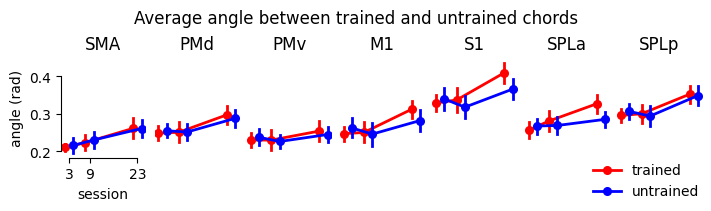

In [22]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

dist_chord_sess['theta'] = np.arccos(dist_chord_sess.cosine)

plot_im_sess(fig, axs, dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average angle between trained and untrained chords')

ttest = ttest_im_sess(dist_chord_sess, rois, y='theta', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/angle_mean.pdf')

plt.show()

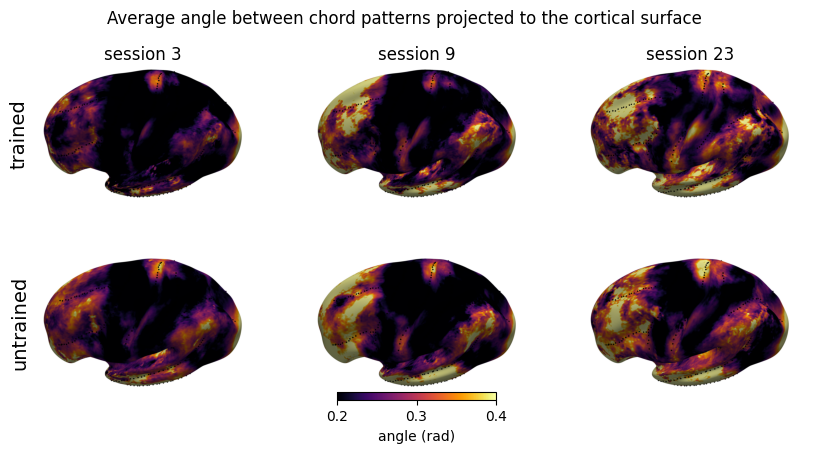

In [10]:
# theta is an angle in radians, so it lives in a different range than the crossnobis map above
thresh = 0
vmin, vmax = .2, .4
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_theta.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('theta-trained')
    untr_col = cols.index('theta-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='angle (rad)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average angle between chord patterns projected to the cortical surface')

fig.savefig('figures/angle_searchlight.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -0.372748   15  0.714550  [-0.02, 0.01]   SMA        3
3  -0.755472   15  0.461665  [-0.02, 0.01]   PMd        3
6  -0.146919   15  0.885152  [-0.03, 0.03]   PMv        3
9  -1.449031   15  0.167912  [-0.08, 0.01]    M1        3
12 -1.314400   15  0.208456  [-0.07, 0.02]    S1        3
15 -1.077956   15  0.298084  [-0.05, 0.01]  SPLa        3
18 -0.476033   15  0.640910  [-0.03, 0.02]  SPLp        3
7  -0.260104   15  0.798320  [-0.04, 0.03]   PMv        9
13  1.129369   15  0.276480  [-0.02, 0.05]    S1        9
10  0.796491   15  0.438172  [-0.02, 0.04]    M1        9
4  -1.016955   15  0.325298  [-0.03, 0.01]   PMd        9
1   0.396977   15  0.696976  [-0.02, 0.02]   SMA        9
16  0.035888   15  0.971845  [-0.03, 0.03]  SPLa        9
19  0.217945   15  0.830409  [-0.02, 0.03]  SPLp        9
5   0.543163   15  0.594997  [-0.02, 0.03]   PMd       23
2   0.374301   15  0.713419  [-0.03, 0.04]   SMA       23
14  1.676830  

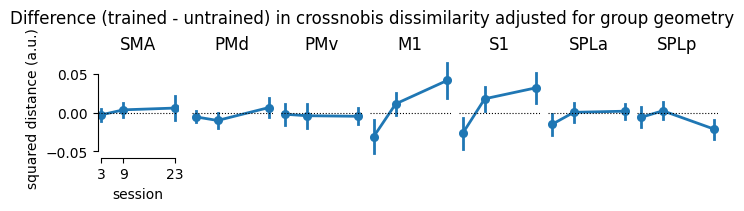

In [25]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist_ancova_crossnobis = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='crossnobis')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_crossnobis, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('squared distance (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in crossnobis dissimilarity adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_crossnobis, rois, y='adjusted', x='session',)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])



plt.show()

           T  dof     p_val           CI95   roi  session
0   0.788320   15  0.442791  [-0.01, 0.02]   SMA        3
3   0.430760   15  0.672769  [-0.01, 0.01]   PMd        3
6   0.369132   15  0.717188  [-0.01, 0.01]   PMv        3
9   1.059769   15  0.306017  [-0.01, 0.02]    M1        3
12  0.438199   15  0.667487  [-0.01, 0.02]    S1        3
15  0.616275   15  0.546952  [-0.01, 0.01]  SPLa        3
18  0.197955   15  0.845738  [-0.01, 0.01]  SPLp        3
7  -0.824166   15  0.422757  [-0.02, 0.01]   PMv        9
13 -1.546038   15  0.142930  [-0.03, 0.01]    S1        9
10 -0.559242   15  0.584251  [-0.02, 0.01]    M1        9
4  -0.674169   15  0.510460  [-0.02, 0.01]   PMd        9
1  -0.645406   15  0.528414  [-0.02, 0.01]   SMA        9
16 -1.398088   15  0.182419   [-0.02, 0.0]  SPLa        9
19 -0.916638   15  0.373835  [-0.02, 0.01]  SPLp        9
5  -1.608548   15  0.128555   [-0.03, 0.0]   PMd       23
2  -0.672319   15  0.511605  [-0.02, 0.01]   SMA       23
14 -2.535260  

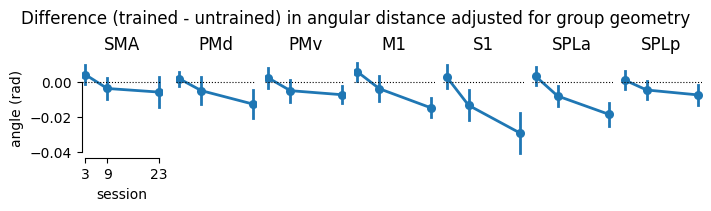

In [31]:
dist_ancova = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity_ancova.within_session.{atlas}.glm{glm}.tsv'), sep='\t')
dist_ancova_cos = dist_ancova[(dist_ancova.Hem==H) & (dist_ancova.metric=='cosine')]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, dist_ancova_cos, rois, y='adjusted', x='session', kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('angle (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Difference (trained - untrained) in angular distance adjusted for group geometry')

ttest = ttest_im_sess(dist_ancova_cos, rois, y='adjusted', x='session',)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])



plt.show()

# Activity vs. dissimilarity
- Activity $a$ for trained and untrained chords was estimated from the cross-validated G-matrix as: $a = \frac{1}{K}\sum_{k=1}^{K}\sqrt{G_{kk}}$; where $K=4$ is the number of chords within the trained and untrained set.

- Dissimilarity $d$ between trained and untrained chords was estimated as the mean off-diagonal crossnobis distance $d = \frac{2}{K(K-1)}\sum_{k<l}\sqrt{D_{kl}}$ over the same conditions, with $D = $ `pcm.G_to_dist(G)`.

- The predicted dissimilarity in session 9 (and 23) if patterns only scaled with activity would be $\hat d_9 = \frac{a_9}{a_3} d_3$; $d_9 - \hat d_9$ (the `residual`) larger than 0 would occur if the patterns separated by more than a change in activity alone can account for.

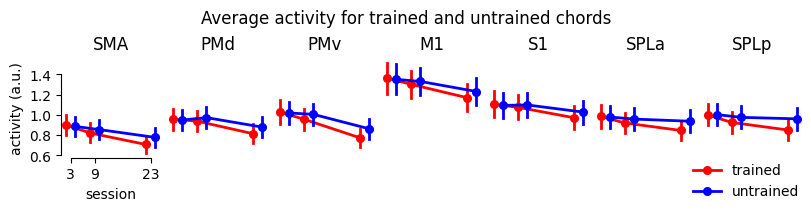

In [13]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='act_target', hue='chord', hue_order=hue_order, palette=palette, estimator='mean', add_zero=False, dodge=.4)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('activity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

fig.suptitle('Average activity for trained and untrained chords')

plt.show()

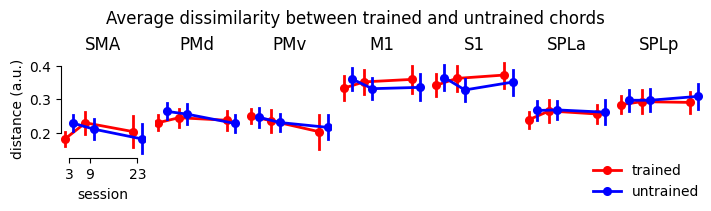

In [14]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(7, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois, y='diss_target_observed', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=False)

sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('distance (a.u.)')

fig.suptitle('Average dissimilarity between trained and untrained chords')

plt.show()

           T  dof     p_val           CI95   roi  session
0        NaN    6       NaN     [nan, nan]   SMA        3
3        NaN   11       NaN     [nan, nan]   PMd        3
6        NaN    8       NaN     [nan, nan]   PMv        3
9        NaN   14       NaN     [nan, nan]    M1        3
12       NaN   14       NaN     [nan, nan]    S1        3
15       NaN   12       NaN     [nan, nan]  SPLa        3
18       NaN   14       NaN     [nan, nan]  SPLp        3
7   0.882260    7  0.406911  [-0.06, 0.14]   PMv        9
13  4.466358   13  0.000635   [0.03, 0.08]    S1        9
10  2.296843   11  0.042266    [0.0, 0.11]    M1        9
4   0.993321    9  0.346507  [-0.02, 0.06]   PMd        9
1   2.707209    4  0.053692   [-0.0, 0.17]   SMA        9
16  2.147399   10  0.057315   [-0.0, 0.08]  SPLa        9
19  1.593522   12  0.137027  [-0.01, 0.07]  SPLp        9
5   2.582881    9  0.029557    [0.0, 0.06]   PMd       23
2   5.270795    1  0.119364  [-0.06, 0.15]   SMA       23
14  3.644413  

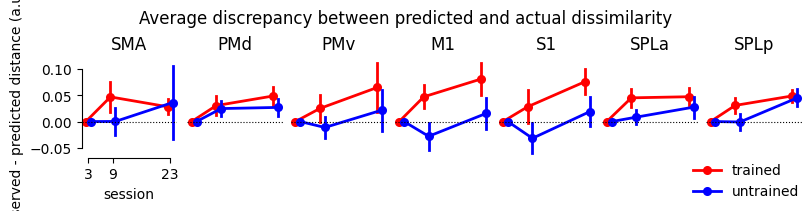

In [15]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')

axs[0].set_ylabel('observed - predicted distance (a.u.)')

fig.suptitle('Average discrepancy between predicted and actual dissimilarity')

ttest = ttest_im_sess(scaling, rois, y='residual', x='session', hue='chord', hue_order=hue_order)
ttest.sort_values(by='session', inplace=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

plt.show()